# Лабораторна робота №3: Візуалізація даних
**Тема:** Робота з графічними даними та багатовимірною візуалізацією.

**Обраний датасет:** Automobile Data Set (UCI Machine Learning Repository).
Відповідає всім вимогам: має категоріальні, цілі та дійсні атрибути, а також містить пропущені значення.

## Завдання 1: Завантаження та Data Cleaning
Завантаження датасету, заміна нестандартних позначень пропусків (знак питання), приведення атрибутів до правильних числових типів та заповнення пропущених значень (медіаною для числових і найчастішим значенням для категоріальних).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", 
           "num-of-doors", "body-style", "drive-wheels", "engine-location", 
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type", 
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke", 
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=columns, na_values="?")

df.dropna(subset=['price'], inplace=True)

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

display(df.head())
print(df.isna().sum().sum())

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


0


## Завдання 2: Графік залежності
Побудова графіка залежності одного integer/real атрибута від іншого. У цьому випадку досліджуємо залежність між споживанням пального на трасі (highway-mpg) та ціною автомобіля (price).

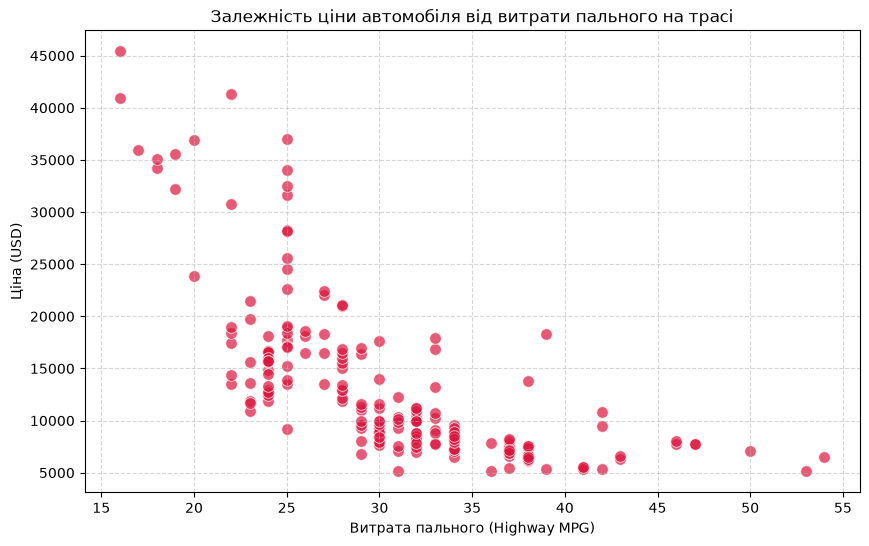

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='highway-mpg', y='price', color='crimson', s=70, alpha=0.7)
plt.title('Залежність ціни автомобіля від витрати пального на трасі')
plt.xlabel('Витрата пального (Highway MPG)')
plt.ylabel('Ціна (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Завдання 3: Гістограма у 5 заданих діапазонах
Побудова гістограми атрибута "horsepower" (кінські сили), розподіленого рівно на 5 заданих діапазонів для оцінки концентрації потужності автомобілів.

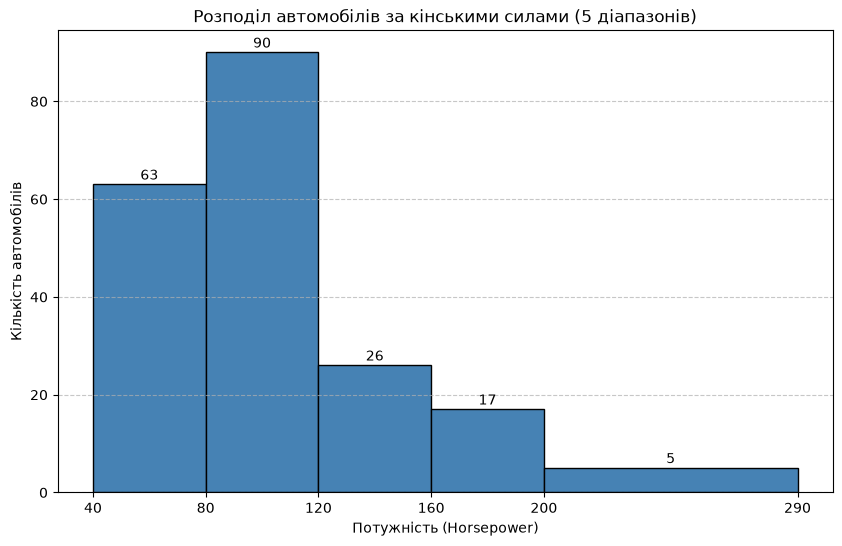

In [3]:
custom_bins = [40, 80, 120, 160, 200, 290]

plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(df['horsepower'], bins=custom_bins, color='steelblue', edgecolor='black')
plt.title('Розподіл автомобілів за кінськими силами (5 діапазонів)')
plt.xlabel('Потужність (Horsepower)')
plt.ylabel('Кількість автомобілів')
plt.xticks(custom_bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(counts)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 1, str(int(counts[i])), ha='center')

plt.show()

## Завдання 4-5: Складна багатовимірна візуалізація та додаткові графіки
Створення графіків для відображення понад двох вимірів (за методологією зі статті на Medium), а також інших корисних візуалізацій для отримання інсайтів (загальна кількість графіків — 6).

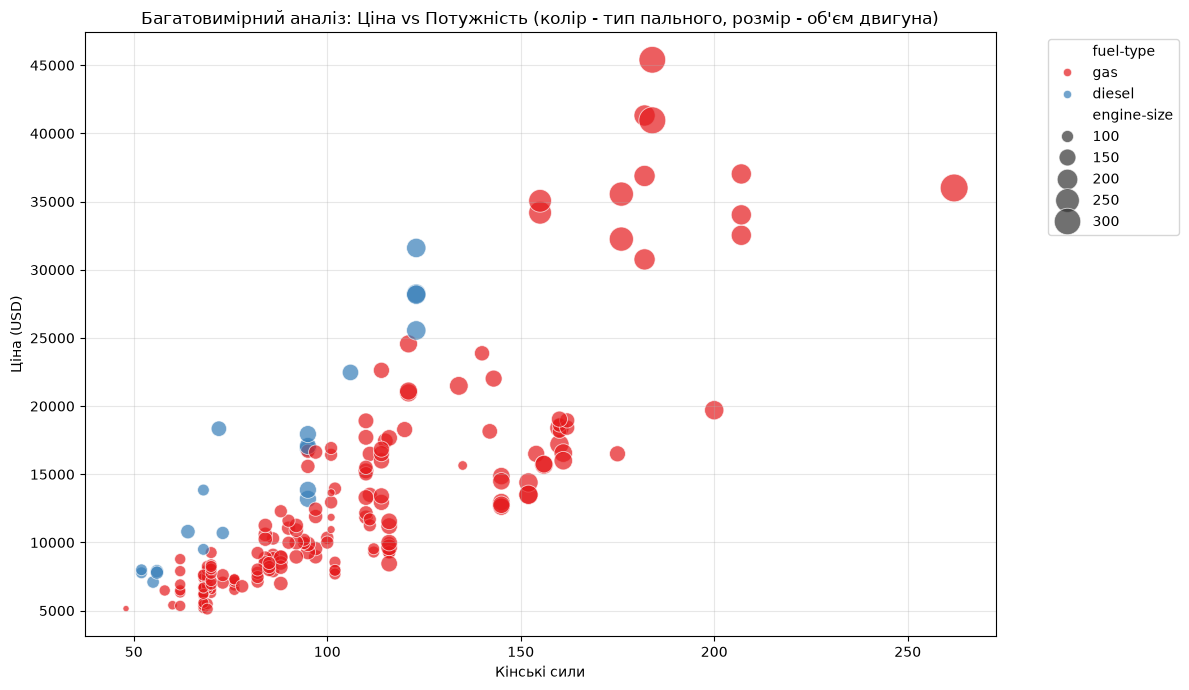

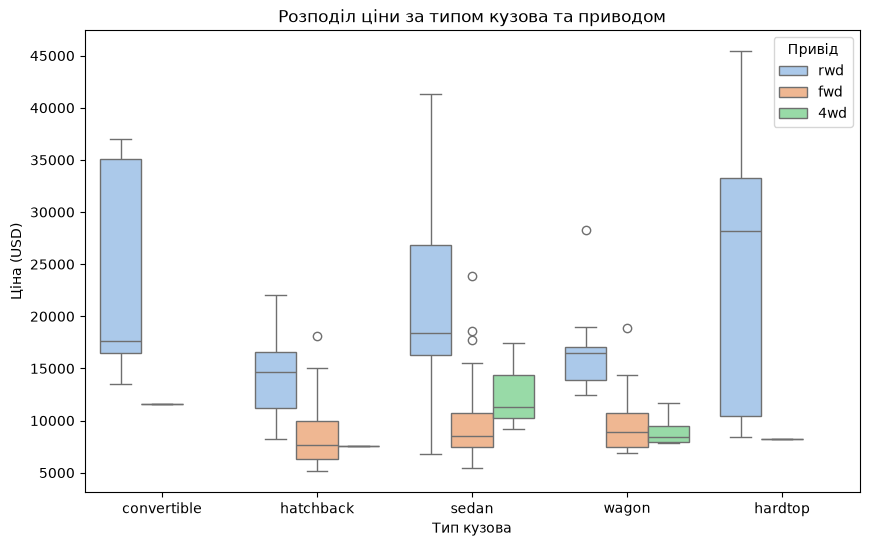

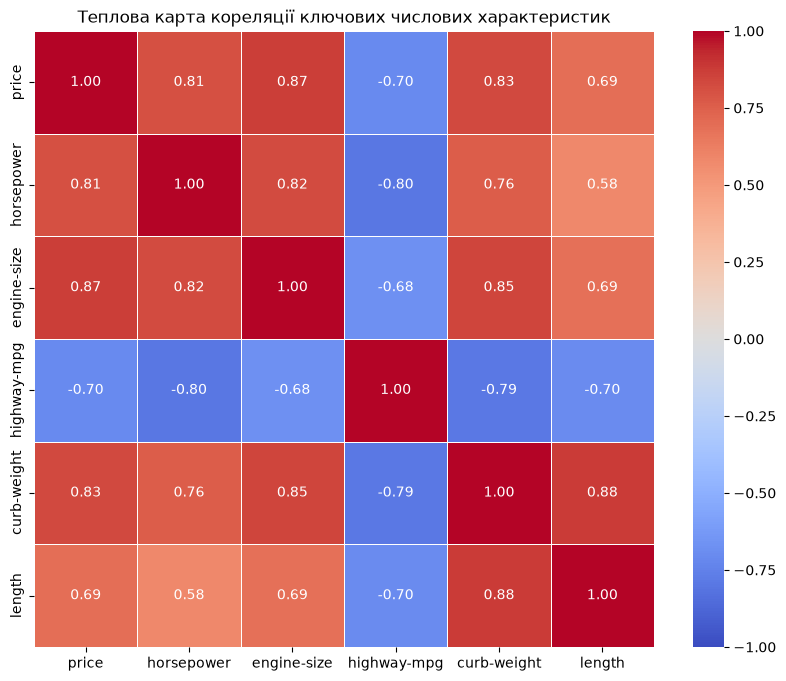

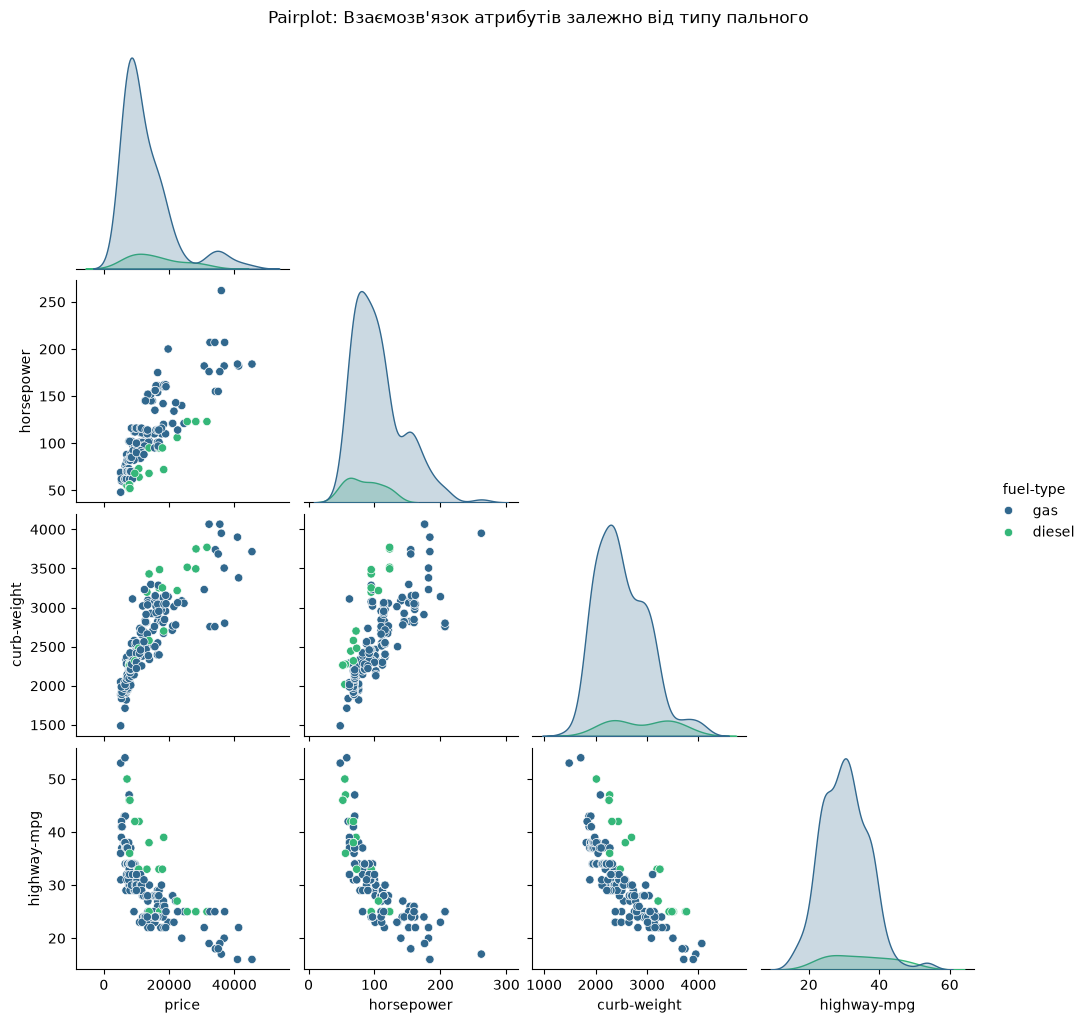

In [4]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='horsepower', y='price', hue='fuel-type', size='engine-size', 
                sizes=(20, 400), alpha=0.7, palette='Set1')
plt.title('Багатовимірний аналіз: Ціна vs Потужність (колір - тип пального, розмір - об\'єм двигуна)')
plt.xlabel('Кінські сили')
plt.ylabel('Ціна (USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='body-style', y='price', hue='drive-wheels', palette='pastel')
plt.title('Розподіл ціни за типом кузова та приводом')
plt.xlabel('Тип кузова')
plt.ylabel('Ціна (USD)')
plt.legend(title='Привід')
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df[['price', 'horsepower', 'engine-size', 'highway-mpg', 'curb-weight', 'length']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Теплова карта кореляції ключових числових характеристик')
plt.show()

sns.pairplot(df[['price', 'horsepower', 'curb-weight', 'highway-mpg', 'fuel-type']], 
             hue='fuel-type', diag_kind='kde', palette='viridis', corner=True)
plt.suptitle('Pairplot: Взаємозв\'язок атрибутів залежно від типу пального', y=1.02)
plt.show()